In [1]:
import h5py
import optuna
from optuna.samplers import TPESampler
from optuna.integration import KerasPruningCallback
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import SGD, Adagrad, Adam, RMSprop
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2

C:\Users\k.fadani\AppData\Local\anaconda3\Lib\importlib\__init__.py:88: FutureWarning: `optuna.integration.keras` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0. Use `optuna_integration.keras` instead.
  return _bootstrap._gcd_import(name[level:], package, level)


In [2]:
brunswick_path = r"C:\Users\k.fadani\Desktop\ei Group project\Brunswick_orig_1500ms_V2.hdf5"

# Open the HDF5 file pointer (mode 'r' for read-only)
f_brunswick = h5py.File(brunswick_path, "r")

# Access the default group where the traces and metadata live
group_brunswick = f_brunswick["TRACE_DATA/DEFAULT"]

# Print available keys to confirm connection
print("Keys available in Brunswick dataset:")
print(list(group_brunswick.keys()))

Keys available in Brunswick dataset:
['ALIAS_FREQ', 'ALIAS_SLOPE', 'AZIMUTH', 'CDP', 'CDPTRACE', 'CDP_X', 'CDP_Y', 'CHANNEL', 'COORD_SCALE', 'COORD_UNIT', 'CORR', 'CROSSLINE', 'DATA_START', 'DATA_STOP', 'DAY', 'DELAY', 'FIRST_BREAK_AMPLIT', 'FIRST_BREAK_TIME', 'FIRST_BREAK_VELOCITY', 'FTRACE', 'GAIN_TYPE', 'GAP_SIZE', 'HIGH_CUT_FREQ', 'HIGH_CUT_SLOPE', 'HORI_SUM', 'HOUR', 'HT_SCALE', 'INLINE', 'INSTR_GAIN_CONSTANT', 'INSTR_INIT_GAIN', 'INTERNAL_SORT1', 'INTERNAL_SORT2', 'LAG_TIME_A', 'LAG_TIME_B', 'LASTTR', 'LINE', 'LOW_CUT_FREQ', 'LOW_CUT_SLOPE', 'MINUTE', 'MODELLED_BREAK_TIME', 'NOTCH_FREQ', 'NOTCH_SLOPE', 'OFFSET', 'OFFSET_FLT', 'OVERTRAVEL', 'RECORDNUM', 'REC_DAT', 'REC_HT', 'REC_NUM_FIRST_FIELD', 'REC_NUM_LAST_FIELD', 'REC_NUM_POS1', 'REC_PEG', 'REC_PEG_DIST', 'REC_STATIC', 'REC_UPHOLE_TIME', 'REC_WATER', 'REC_X', 'REC_Y', 'REEL', 'REF_MODEL_REC_STATIC', 'REF_MODEL_SRC_STATIC', 'REF_RESID_REC_STATIC', 'REF_RESID_SRC_STATIC', 'REF_TOTAL_STATIC', 'REPEAT', 'SAMP_NUM', 'SAMP_RATE', '

In [3]:
group_brunswick['SPARE1'].shape

(4496540, 1)

In [4]:
# Selecting the important keys from keys mentioned in the task requirements
keys_to_extract = [
    'SHOTID',
    'SHOT_PEG',
    'SOURCE_X',
    'SOURCE_Y',
    'REC_PEG',
    'REC_X',
    'REC_Y',
    'SAMP_RATE',
    'COORD_SCALE',
    'HT_SCALE',
    'SAMP_NUM',
    'SPARE1',  # First break time in ms
]

# Extract arrays into a Pandas DataFrame
df_meta = pd.DataFrame(
    {key: group_brunswick[key][:, 0] for key in keys_to_extract}
)

#Total traces
print(f"Total number of traces in Brunswick: {len(df_meta)}")

Total number of traces in Brunswick: 4496540


In [5]:
df_meta

,SHOTID,SHOT_PEG,SOURCE_X,SOURCE_Y,REC_PEG,REC_X,REC_Y,SAMP_RATE,COORD_SCALE,HT_SCALE,SAMP_NUM,SPARE1
0,1,11108,2876700,52530740,361001,2876600,52566020,2000,-10,-10,751,-1
1,1,11108,2876700,52530740,361002,2876390,52565920,2000,-10,-10,751,638
2,1,11108,2876700,52530740,361003,2876200,52565830,2000,-10,-10,751,-1
3,1,11108,2876700,52530740,361004,2876000,52565740,2000,-10,-10,751,638
4,1,11108,2876700,52530740,361005,2875800,52565640,2000,-10,-10,751,638
...,...,...,...,...,...,...,...,...,...,...,...,...
4496535,1817,231004,2832640,52593200,261274,2821990,52556550,2000,-10,-10,751,753
4496536,1817,231004,2832640,52593200,261275,2821780,52556460,2000,-10,-10,751,756
4496537,1817,231004,2832640,52593200,261276,2821580,52556360,2000,-10,-10,751,759
4496538,1817,231004,2832640,52593200,261277,2821380,52556270,2000,-10,-10,751,762


In [6]:
df_meta.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
SHOTID,4496540.0,8.984813e+02,498.573264,1.0,487.0,907.0,1303.0,1817.0
SHOT_PEG,4496540.0,1.522649e+05,86030.805424,11004.0,71088.0,151069.0,231040.0,291117.0
SOURCE_X,4496540.0,2.848498e+06,17215.722078,2820280.0,2832740.0,2848690.0,2864660.0,2876920.0
SOURCE_Y,4496540.0,5.255950e+07,19300.773434,52524640.0,52543300.0,52559500.0,52575110.0,52594910.0
REC_PEG,4496540.0,3.196060e+05,114675.019688,41240.0,241005.0,321147.0,401228.0,581067.0
REC_X,4496540.0,2.848683e+06,15919.909112,2820760.0,2835000.0,2848640.0,2862390.0,2876630.0
REC_Y,4496540.0,5.255964e+07,18222.974958,52524420.0,52545060.0,52559510.0,52574310.0,52594940.0
SAMP_RATE,4496540.0,2.000000e+03,0.000000,2000.0,2000.0,2000.0,2000.0,2000.0
COORD_SCALE,4496540.0,-1.000000e+01,0.000000,-10.0,-10.0,-10.0,-10.0,-10.0
HT_SCALE,4496540.0,-1.000000e+01,0.000000,-10.0,-10.0,-10.0,-10.0,-10.0


Shot ID 1 contains 2582 seismic traces.


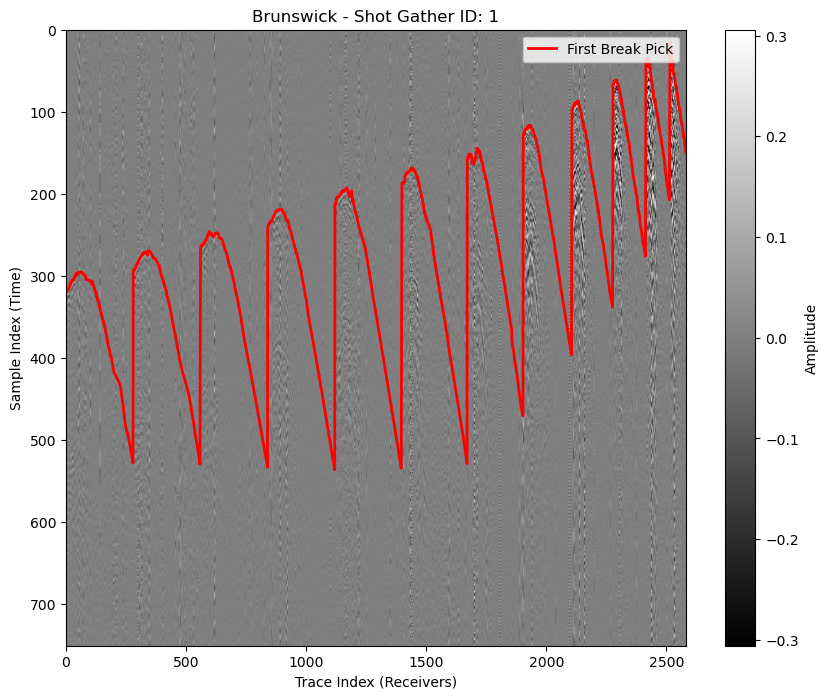

In [7]:
# 1. Grab the first unique SHOTID from our metadata table
first_shot_id = df_meta['SHOTID'].iloc[0]

# 2. Get the row indices in df_meta corresponding to this SHOTID
shot_indices = df_meta[df_meta['SHOTID'] == first_shot_id].index.values

print(
    f'Shot ID {first_shot_id} contains {len(shot_indices)} seismic traces.'
)

# 3. Pull the 2D amplitude matrix for these specific traces from HDF5 `data_array`
shot_gather_data = group_brunswick['data_array'][shot_indices, :]

# 4. Pull the target SPARE1 time picks (in ms) for these traces
spare1_times = df_meta.loc[shot_indices, 'SPARE1'].values

# 5. Convert SPARE1 time (ms) to sample pixel index
samp_rate = df_meta.loc[shot_indices[0], 'SAMP_RATE']
pick_sample_indices = (spare1_times * 1000.0) / samp_rate

# Filter out unlabeled (-1 or 0) picks for visualization
valid_mask = spare1_times > 0
trace_x_coords = np.arange(len(shot_indices))

# 6. Plot the Shot Gather Image + Red Target Line
plt.figure(figsize=(10, 8))

# Transpose matrix (.T) so Y-axis is Time (samples) and X-axis is Receiver Traces
std_dev = np.std(shot_gather_data)
plt.imshow(
    shot_gather_data.T,
    cmap='gray',
    aspect='auto',
    vmin=-2 * std_dev,
    vmax=2 * std_dev,
)

# Plot valid target picks as a red line
plt.plot(
    trace_x_coords[valid_mask],
    pick_sample_indices[valid_mask],
    color='red',
    linewidth=2,
    label='First Break Pick',
)

plt.title(f'Brunswick - Shot Gather ID: {first_shot_id}')
plt.xlabel('Trace Index (Receivers)')
plt.ylabel('Sample Index (Time)')
plt.legend(loc='upper right')
plt.colorbar(label='Amplitude')
plt.show()

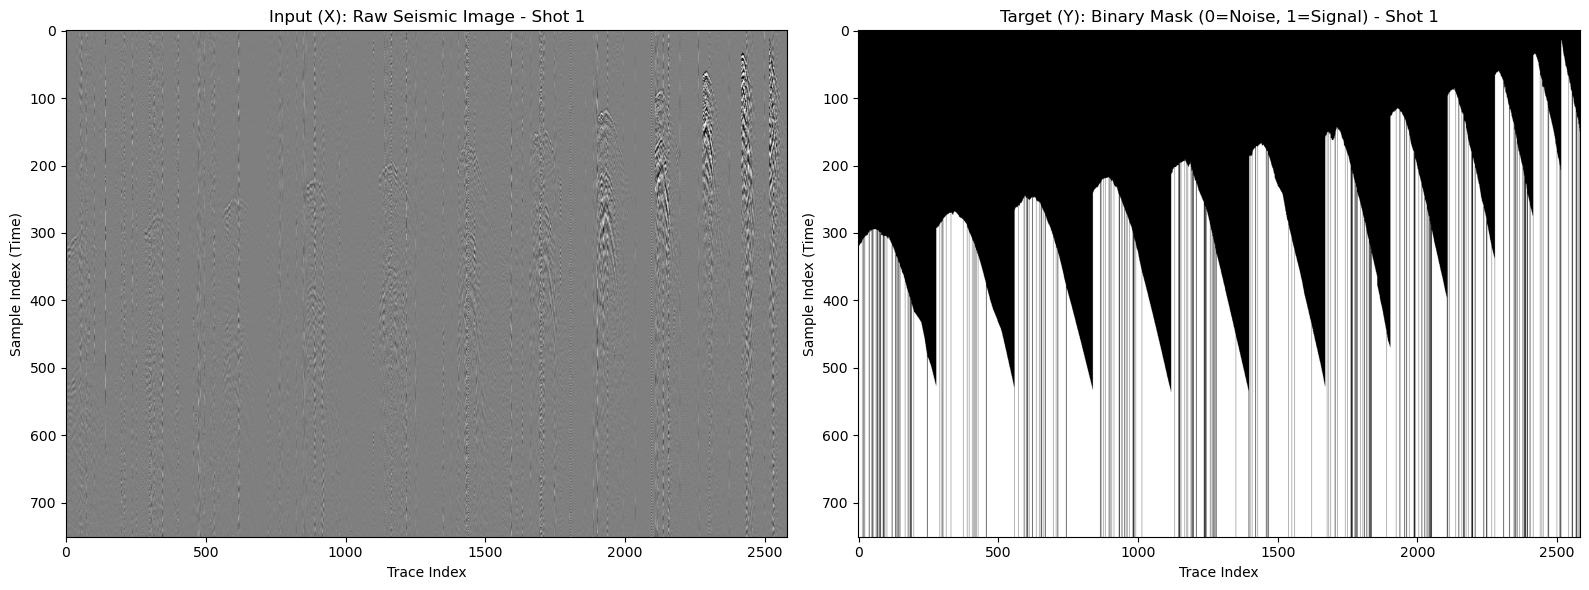

In [8]:
def create_binary_mask(shot_matrix, pick_indices):
    """Generates a 2D binary mask from pick row indices.

    - Pixels BEFORE arrival time (sample < pick) = 0
    - Pixels AT/AFTER arrival time (sample >= pick) = 1
    """
    n_samples, n_traces = shot_matrix.shape
    mask = np.zeros((n_samples, n_traces), dtype=np.float32)

    for trace_idx in range(n_traces):
        pick = pick_indices[trace_idx]
        # Only draw mask for valid picks (pick > 0)
        if pick > 0 and not np.isnan(pick):
            mask[int(pick) :, trace_idx] = 1.0

    return mask


# 1. Create binary mask for Shot 1
# shot_gather_data shape is (2582, 751), so we transpose it to (751, 2582)
shot_image = shot_gather_data.T
binary_mask = create_binary_mask(shot_image, pick_sample_indices)

# 2. Visual Check: Compare Input Image vs Target Mask
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Raw Seismic Input (X)
std_dev = np.std(shot_image)
ax1.imshow(
    shot_image,
    cmap='gray',
    aspect='auto',
    vmin=-2 * std_dev,
    vmax=2 * std_dev,
)
ax1.set_title(f'Input (X): Raw Seismic Image - Shot {first_shot_id}')
ax1.set_xlabel('Trace Index')
ax1.set_ylabel('Sample Index (Time)')

# Subplot 2: Binary Target Mask (Y)
ax2.imshow(binary_mask, cmap='gray', aspect='auto')
ax2.set_title(f'Target (Y): Binary Mask (0=Noise, 1=Signal) - Shot {first_shot_id}')
ax2.set_xlabel('Trace Index')
ax2.set_ylabel('Sample Index (Time)')

plt.tight_layout()
plt.show()

In [9]:
def prepare_patches_from_gather(
    shot_matrix, binary_mask, patch_width=256, target_height=768
):
    """Resizes time axis to target_height (768) and splits wide shot gathers into

    patches of standard width (256).
    """
    # 1. Resize height to target_height (768)
    # shot_matrix shape: (751, num_traces) -> (768, num_traces)
    resized_img = cv2.resize(
        shot_matrix,
        (shot_matrix.shape[1], target_height),
        interpolation=cv2.INTER_LINEAR,
    )

    # Use Nearest Neighbor interpolation for binary mask to keep values strictly 0 or 1
    resized_mask = cv2.resize(
        binary_mask,
        (binary_mask.shape[1], target_height),
        interpolation=cv2.INTER_NEAREST,
    )

    # 2. Z-Score Normalization (Mean=0, Std=1) for seismic amplitudes
    mean = np.mean(resized_img)
    std = np.std(resized_img) + 1e-8
    normalized_img = (resized_img - mean) / std

    # 3. Slice width into patches of size 256
    num_traces = normalized_img.shape[1]
    img_patches = []
    mask_patches = []

    for start_x in range(0, num_traces, patch_width):
        end_x = start_x + patch_width
        if end_x <= num_traces:
            img_patch = normalized_img[:, start_x:end_x]
            mask_patch = resized_mask[:, start_x:end_x]

            # Add channel dimension for Keras (Height, Width, Channels)
            img_patches.append(np.expand_dims(img_patch, axis=-1))
            mask_patches.append(np.expand_dims(mask_patch, axis=-1))

    return np.array(img_patches), np.array(mask_patches)


# Test patching on Shot 1
X_patches, y_patches = prepare_patches_from_gather(shot_image, binary_mask)

print(f"Original shot gather shape: {shot_image.shape}")
print(
    f"Generated {X_patches.shape[0]} patches, each of shape: {X_patches.shape[1:]}"
)

Original shot gather shape: (751, 2582)
Generated 10 patches, each of shape: (768, 256, 1)


In [10]:
def process_dataset(
    file_path, max_shots=50, patch_width=256, target_height=768
):
    """Loads shot gathers from an HDF5 file, generates binary masks,

    and returns normalized (X, y) patch arrays.
    """
    f = h5py.File(file_path, 'r')
    group = f['TRACE_DATA/DEFAULT']

    # Read necessary metadata keys
    shot_ids = group['SHOTID'][:]
    spare1 = group['SPARE1'][:]
    samp_rate = group['SAMP_RATE'][0]

    unique_shots = np.unique(shot_ids)[:max_shots]

    X_list, y_list = [], []

    for s_id in unique_shots:
        # Find trace indices belonging to this shot
        indices = np.where(shot_ids == s_id)[0]
        if len(indices) < patch_width:
            continue

        # Extract seismic amplitude matrix and transpose to (Time, Receivers)
        shot_matrix = group['data_array'][indices, :].T
        spare1_times = spare1[indices]

        # Convert SPARE1 arrival times (ms) to sample pixel indices
        pick_indices = (spare1_times * 1000.0) / samp_rate

        # Generate binary mask
        mask = create_binary_mask(shot_matrix, pick_indices)

        # Generate patches
        x_p, y_p = prepare_patches_from_gather(
            shot_matrix,
            mask,
            patch_width=patch_width,
            target_height=target_height,
        )

        if len(x_p) > 0:
            X_list.append(x_p)
            y_list.append(y_p)

    f.close()

    if len(X_list) == 0:
        return np.empty((0, target_height, patch_width, 1)), np.empty(
            (0, target_height, patch_width, 1)
        )

    return np.vstack(X_list), np.vstack(y_list)


# 1. Process Training Datasets
print('Processing Brunswick...')
X_brun, y_brun = process_dataset(r"C:\Users\k.fadani\Desktop\ei Group project\Brunswick_orig_1500ms_V2.hdf5", max_shots=50)

print('Processing Lalor...')
X_lal, y_lal = process_dataset(
    r"C:\Users\k.fadani\Desktop\ei Group project\Lalor_raw_z_1500ms_norp_geom_v3.hdf5", max_shots=50
)

print('Processing Sudbury...')
X_sud, y_sud = process_dataset(r"C:\Users\k.fadani\Desktop\ei Group project\preprocessed_Sudbury3D.hdf", max_shots=50)

# Combine training datasets into a single array
X_train = np.concatenate([X_brun, X_lal, X_sud], axis=0)
y_train = np.concatenate([y_brun, y_lal, y_sud], axis=0)

# 2. Process Hold-out Deployment Dataset (Halfmile)
print('Processing Halfmile (Validation/Deployment)...')
X_val, y_val = process_dataset(
    r"C:\Users\k.fadani\Desktop\ei Group project\Halfmile3D_add_geom_sorted.hdf5", max_shots=30
)

print('\n--- PIPELINE SUMMARY ---')
print(f'Training Set Shapes   -> X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'Validation Set Shapes -> X_val: {X_val.shape}, y_val: {y_val.shape}')

Processing Brunswick...


C:\Users\k.fadani\AppData\Local\Temp\ipykernel_15548\4053711600.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mask[int(pick) :, trace_idx] = 1.0


Processing Lalor...
Processing Sudbury...
Processing Halfmile (Validation/Deployment)...

--- PIPELINE SUMMARY ---
Training Set Shapes   -> X_train: (1208, 768, 256, 1), y_train: (1208, 768, 256, 1)
Validation Set Shapes -> X_val: (180, 768, 256, 1), y_val: (180, 768, 256, 1)


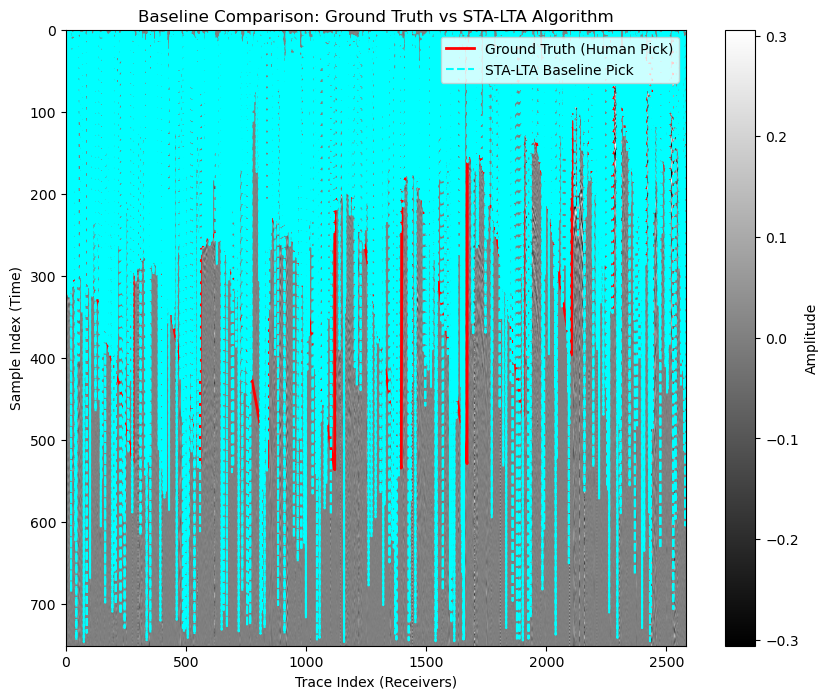

STA-LTA Baseline Mean Absolute Error (MAE): 407.30 ms


In [11]:
def compute_sta_lta_trace(trace, n_sta=10, n_lta=100):
    """Computes the Short-Term Average / Long-Term Average ratio for a 1D seismic trace."""
    sta = (
        np.convolve(
            trace**2, np.ones(n_sta) / n_sta, mode='same'
        )
        + 1e-8
    )
    lta = (
        np.convolve(
            trace**2, np.ones(n_lta) / n_lta, mode='same'
        )
        + 1e-8
    )
    return sta / lta


def sta_lta_picker_gather(shot_matrix, threshold=2.5, n_sta=10, n_lta=100):
    """Runs STA-LTA picking across all traces in a 2D shot gather matrix."""
    n_samples, n_traces = shot_matrix.shape
    predicted_pick_samples = np.zeros(n_traces)

    for i in range(n_traces):
        ratio = compute_sta_lta_trace(
            shot_matrix[:, i], n_sta=n_sta, n_lta=n_lta
        )
        # Find the first sample index where STA/LTA ratio exceeds threshold
        above_threshold = np.where(ratio > threshold)[0]
        if len(above_threshold) > 0:
            predicted_pick_samples[i] = above_threshold[0]
        else:
            predicted_pick_samples[i] = 0

    return predicted_pick_samples


# 1. Run STA-LTA on our test Shot 1 image
sta_lta_picks = sta_lta_picker_gather(
    shot_image, threshold=3.0, n_sta=10, n_lta=100
)

# 2. Plot STA-LTA Picks vs Ground Truth
plt.figure(figsize=(10, 8))
std_dev = np.std(shot_image)
plt.imshow(
    shot_image,
    cmap='gray',
    aspect='auto',
    vmin=-2 * std_dev,
    vmax=2 * std_dev,
)

# Plot Ground Truth (Red) vs STA-LTA Baseline (Cyan)
plt.plot(
    trace_x_coords[valid_mask],
    pick_sample_indices[valid_mask],
    color='red',
    linewidth=2,
    label='Ground Truth (Human Pick)',
)
plt.plot(
    trace_x_coords,
    sta_lta_picks,
    color='cyan',
    linestyle='--',
    linewidth=1.5,
    label='STA-LTA Baseline Pick',
)

plt.title('Baseline Comparison: Ground Truth vs STA-LTA Algorithm')
plt.xlabel('Trace Index (Receivers)')
plt.ylabel('Sample Index (Time)')
plt.legend(loc='upper right')
plt.colorbar(label='Amplitude')
plt.show()

# 3. Calculate STA-LTA Baseline MAE (Mean Absolute Error) in Milliseconds
samp_rate_ms = samp_rate / 1000.0  # 2000 us = 2.0 ms
valid_indices = np.where(valid_mask)[0]

true_times_ms = spare1_times[valid_indices]
pred_times_ms = sta_lta_picks[valid_indices] * samp_rate_ms

mae_sta_lta = np.mean(np.abs(true_times_ms - pred_times_ms))
print(f'STA-LTA Baseline Mean Absolute Error (MAE): {mae_sta_lta:.2f} ms')

In [12]:
def build_unet(input_shape=(768, 256, 1)):
    inputs = layers.Input(input_shape)

    # --- ENCODER ---
    # Block 1
    c1 = layers.Conv2D(
        16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(inputs)
    c1 = layers.Conv2D(
        16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # Block 2
    c2 = layers.Conv2D(
        32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(p1)
    c2 = layers.Conv2D(
        32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Block 3
    c3 = layers.Conv2D(
        64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(p2)
    c3 = layers.Conv2D(
        64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # --- BOTTLENECK ---
    c4 = layers.Conv2D(
        128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(p3)
    c4 = layers.Conv2D(
        128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(c4)

    # --- DECODER ---
    # Block 5 (Upsample 3)
    u5 = layers.UpSampling2D((2, 2))(c4)
    u5 = layers.Concatenate()([u5, c3])
    c5 = layers.Conv2D(
        64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(u5)
    c5 = layers.Conv2D(
        64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(c5)

    # Block 6 (Upsample 2)
    u6 = layers.UpSampling2D((2, 2))(c5)
    u6 = layers.Concatenate()([u6, c2])
    c6 = layers.Conv2D(
        32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(u6)
    c6 = layers.Conv2D(
        32, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(c6)

    # Block 7 (Upsample 1)
    u7 = layers.UpSampling2D((2, 2))(c6)
    u7 = layers.Concatenate()([u7, c1])
    c7 = layers.Conv2D(
        16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(u7)
    c7 = layers.Conv2D(
        16, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal'
    )(c7)

    # Output binary mask prediction (0 to 1)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c7)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model


# Instantiate and view model summary
model = build_unet(input_shape=(768, 256, 1))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 768, 256, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 768, 256, 16)      │             160 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 768, 256, 16)      │           2,320 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d (MaxPooling2D)  │ (None, 384, 128, 16)      │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 384, 128, 32)      │           4,640 │ max_pooling2d[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 384, 128, 32)      │           9,248 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_1               │ (None, 192, 64, 32)       │               0 │ conv2d_3[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 192, 64, 64)       │          18,496 │ max_pooling2d_1[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 192, 64, 64)       │          36,928 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_2               │ (None, 96, 32, 64)        │               0 │ conv2d_5[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 96, 32, 128)       │          73,856 │ max_pooling2d_2[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 96, 32, 128)       │         147,584 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ up_sampling2d (UpSampling2D)  │ (None, 192, 64, 128)      │               0 │ conv2d_7[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 192, 64, 192)      │               0 │ up_sampling2d[0][0],       │
│                               │                           │                 │ conv2d_5[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 192, 64, 64)       │         110,656 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 192, 64, 64)       │          36,92

 Total params: 487,009 (1.86 MB)

 Trainable params: 487,009 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# 1. Compile the Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)],
)

# 2. Callbacks for Optimal Training
callbacks = [
    EarlyStopping(
        patience=5, monitor='val_loss', restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        factor=0.5, patience=2, monitor='val_loss', min_lr=1e-6, verbose=1
    ),
]

# 3. Train the U-Net Model on All Combined Training Datasets!
# (X_train & y_train hold data from Brunswick, Lalor, and Sudbury)
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),  # Halfmile validation set
    epochs=20,
    batch_size=4,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 894s 3s/step - accuracy: 0.7345 - loss: 0.5011 - mean_io_u_1: 0.2976 - val_accuracy: 0.7734 - val_loss: 0.4790 - val_mean_io_u_1: 0.1647 - learning_rate: 0.0010
Epoch 2/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 860s 3s/step - accuracy: 0.7392 - loss: 0.4928 - mean_io_u_1: 0.2977 - val_accuracy: 0.9018 - val_loss: 0.3849 - val_mean_io_u_1: 0.1647 - learning_rate: 0.0010
Epoch 3/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 859s 3s/step - accuracy: 0.7473 - loss: 0.4816 - mean_io_u_1: 0.2976 - val_accuracy: 0.8428 - val_loss: 0.4185 - val_mean_io_u_1: 0.1647 - learning_rate: 0.0010
Epoch 4/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 924s 3s/step - accuracy: 0.7547 - loss: 0.4731 - mean_io_u_1: 0.2977 - val_accuracy: 0.9150 - val_loss: 0.2958 - val_mean_io_u_1: 0.1648 - learning_rate: 0.0010
Epoch 5/20
302/302 ━━━━━━━━━━━━━━━━━━━━ 853s 3s/step - accuracy: 0.7679 - loss: 0.4568 - mean_io_u_1: 0.2977 - val_accuracy: 0.9029 - val_loss: 0.3313 - val_mean_io_u_1: 0.1648 - learning_rate: 0.

In [17]:
def mask_to_pick_times(pred_mask, original_height=751, samp_rate_us=2000.0):
    """Finds the first row in each trace column where predicted probability >= 0.5

    and converts it back to millisecond arrival time.
    """
    n_samples, n_traces, _ = pred_mask.shape
    predicted_picks_ms = []

    samp_rate_ms = samp_rate_us / 1000.0  # 2.0 ms

    for col in range(n_traces):
        trace_probs = pred_mask[:, col, 0]
        above_threshold = np.where(trace_probs >= 0.5)[0]

        if len(above_threshold) > 0:
            # Map back from 768 resized height to 751 original scale
            resized_pick_idx = above_threshold[0]
            original_sample_idx = (
                resized_pick_idx / float(n_samples)
            ) * original_height
            pick_time_ms = original_sample_idx * samp_rate_ms
        else:
            pick_time_ms = 0.0

        predicted_picks_ms.append(pick_time_ms)

    return np.array(predicted_picks_ms)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step

U-Net Deployment MAE on Halfmile: 37.12 ms



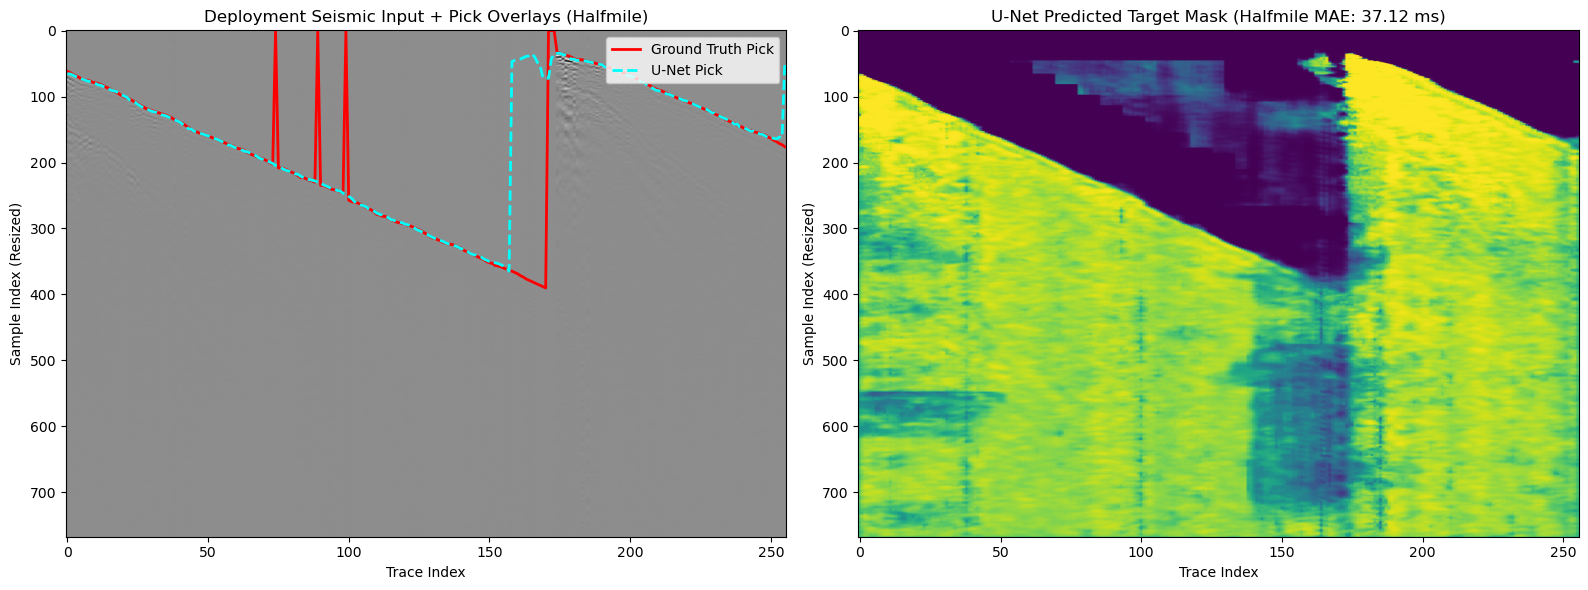

In [18]:
# 1. Select a test patch from Halfmile validation set
test_idx = 0
sample_x = X_val[test_idx : test_idx + 1]
sample_y_true = y_val[test_idx]

# 2. Predict mask using trained U-Net
sample_y_pred = model.predict(sample_x)[0]

# 3. Extract time picks
true_picks = mask_to_pick_times(sample_y_true)
pred_picks = mask_to_pick_times(sample_y_pred)

# 4. Calculate Mean Absolute Error (MAE)
valid_mask_eval = true_picks > 0
mae_unet = np.mean(
    np.abs(true_picks[valid_mask_eval] - pred_picks[valid_mask_eval])
)

print('\n========================================')
print(f'U-Net Deployment MAE on Halfmile: {mae_unet:.2f} ms')
print('========================================\n')

# 5. Plot Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Input Seismic Patch + Pick Overlay
ax1.imshow(sample_x[0, :, :, 0], cmap='gray', aspect='auto')
ax1.plot(
    true_picks / 2.0, color='red', linewidth=2, label='Ground Truth Pick'
)
ax1.plot(
    pred_picks / 2.0,
    color='cyan',
    linestyle='--',
    linewidth=2,
    label='U-Net Pick',
)
ax1.set_title('Deployment Seismic Input + Pick Overlays (Halfmile)')
ax1.set_xlabel('Trace Index')
ax1.set_ylabel('Sample Index (Resized)')
ax1.legend(loc='upper right')

# Subplot 2: Predicted Probability Mask
ax2.imshow(sample_y_pred[:, :, 0], cmap='viridis', aspect='auto')
ax2.set_title(
    f'U-Net Predicted Target Mask (Halfmile MAE: {mae_unet:.2f} ms)'
)
ax2.set_xlabel('Trace Index')
ax2.set_ylabel('Sample Index (Resized)')

plt.tight_layout()
plt.show()